In [12]:
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv('retail_store_sales.csv')
data

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [13]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [14]:
data.columns[data.isnull().any()]

Index(['Item', 'Price Per Unit', 'Quantity', 'Total Spent',
       'Discount Applied'],
      dtype='str')

In [15]:
data

output=data.groupby("Category")["Item"].value_counts()
#print(output.to_string())
popular=data.groupby(by="Category")["Item"].agg(lambda x: x.mode()[0])
print(popular.to_string())

data["Item"]=data["Item"].fillna(data["Category"].map(popular))

print(data["Item"].isnull().sum())

Category
Beverages                               Item_2_BEV
Butchers                               Item_20_BUT
Computers and electric accessories     Item_19_CEA
Electric household essentials           Item_8_EHE
Food                                  Item_14_FOOD
Furniture                              Item_25_FUR
Milk Products                         Item_16_MILK
Patisserie                             Item_12_PAT
0


In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              12575 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [17]:
data[["Category","Item","Price Per Unit"]].sort_values(by="Item")
t=data.loc[data["Price Per Unit"].isnull(),["Category","Item","Price Per Unit"]]
unq=data["Item"].unique()
unq

mask=data.groupby(by="Item")["Price Per Unit"].mean()
mask.sort_values()

data["Price Per Unit"]=data["Price Per Unit"].fillna(data["Item"].map(mask))
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              12575 non-null  str    
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [18]:
data[["Item","Quantity","Price Per Unit","Total Spent"]].sort_values(by="Item")

mask_quantity=data.groupby(by="Item")["Quantity"].median()
data["Quantity"]=data["Quantity"].fillna(data["Item"].map(mask_quantity))

data["Total Spent"]=data["Total Spent"].fillna(data["Quantity"]*data["Price Per Unit"])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              12575 non-null  str    
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [19]:
x=data.groupby(by="Item")["Discount Applied"].value_counts()
#print(x.to_string())
mask_discount=data.groupby(by="Item")["Discount Applied"].agg(lambda x: x.mode()[0])
data["Discount Applied"]=data["Discount Applied"].fillna(data["Item"].map(mask_discount))
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              12575 non-null  str    
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  12575 non-null  object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [20]:
data["Category"].value_counts()

Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

In [21]:
#In the previous steps, we performed data imputation by replacing missing values (NaN) with values that were considered the most appropriate for each situation.

In [22]:
data.duplicated().sum()
#it shows that we don't have duplicated rows

np.int64(0)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Furniture'),
  Text(1, 0, 'Electric household essentials'),
  Text(2, 0, 'Food'),
  Text(3, 0, 'Milk Products'),
  Text(4, 0, 'Butchers'),
  Text(5, 0, 'Beverages'),
  Text(6, 0, 'Computers and electric accessories'),
  Text(7, 0, 'Patisserie')])

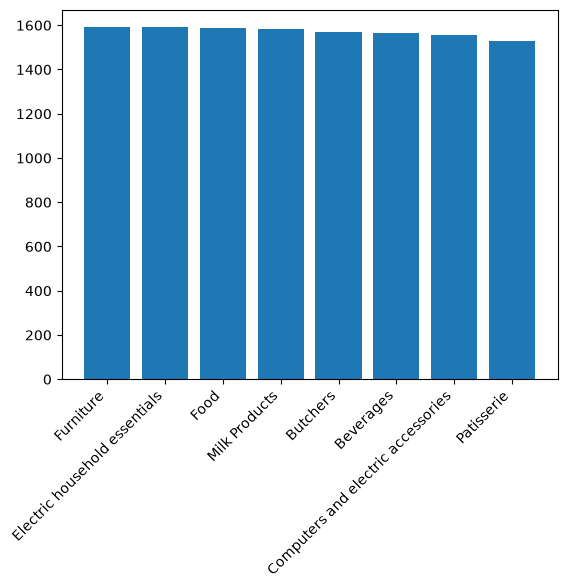

In [36]:
ctg=data["Category"].value_counts()
plt.bar(x=ctg.index,height=ctg.values)
plt.xticks(rotation=45,ha='right')

In [ ]:
#Barplot shows that amount of products in each category is almost equal

[1528, 1558, 1567, 1568, 1584, 1588, 1591, 1591]


(array([1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(1, 0, 'Patisserie'),
  Text(2, 0, 'Milk Products'),
  Text(3, 0, 'Butchers'),
  Text(4, 0, 'Beverages'),
  Text(5, 0, 'Food'),
  Text(6, 0, 'Furniture'),
  Text(7, 0, 'Electric household essentials'),
  Text(8, 0, 'Computers and electric accessories')])

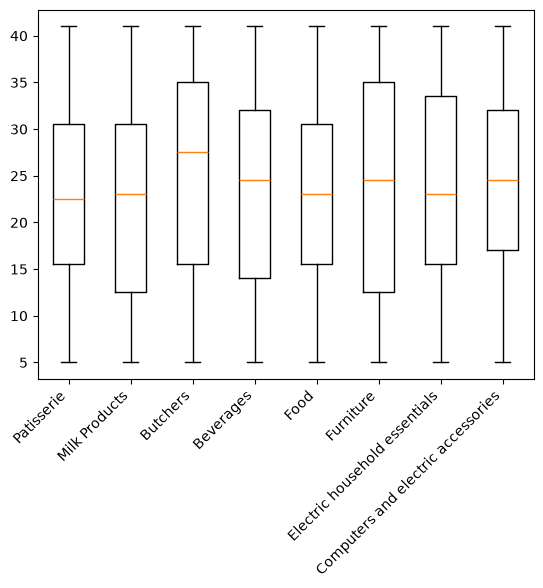

In [58]:
ctg_prices=data[["Category","Price Per Unit"]].sort_values(by="Category")
ctg_unq=data["Category"].unique()
prices_dict={}
for ctg in ctg_unq:
    prices_dict[ctg]=list(data[data["Category"]==ctg]["Price Per Unit"])
plt.boxplot(prices_dict.values(),tick_labels=prices_dict.keys())
plt.xticks(rotation=45,ha='right')

In [ ]:
#The multiple boxplots show the distribution of prices across different product categories. Based on the visualization, we can conclude that there are no significant outliers, and the minimum and maximum prices are the same for all categories.The main difference between the categories is the median price. For example, the median price in the Patisserie category is approximately 22.5, while in the Butchers category it is around 27.5. The price distribution of middle 50% of observations varies between categories; for example, in the Food category, 50% of observations are concentrated between approximately 16 and 30, while in the Milk Products category, the middle 50% of prices are between approximately 12.5 and 30.

<BarContainer object of 3 artists>

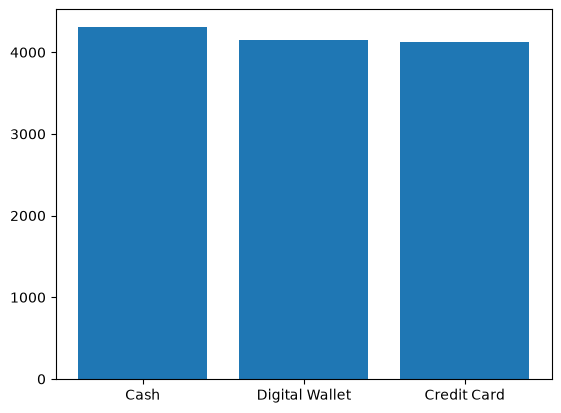

In [68]:
pmnt=data["Payment Method"].value_counts()
pmnt
plt.bar(x=pmnt.index,height=pmnt.values)

In [ ]:
#this show that every payment method was used similar number of times, but most popular was Cash


<BarContainer object of 2 artists>

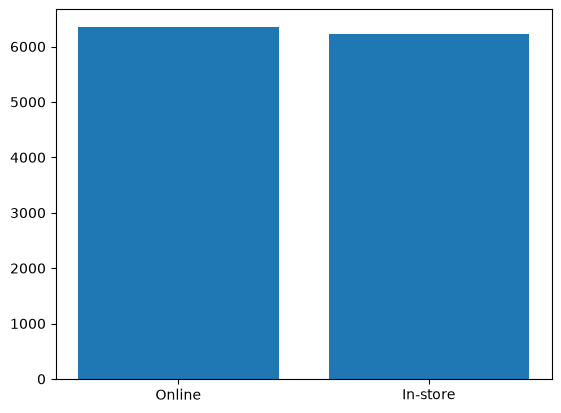

In [69]:
location=data["Location"].value_counts()
location
plt.bar(x=location.index,height=location.values)

In [ ]:
#Online transactions have similar popularity to In-store transactions

In [71]:
#max spent by category
totalSpent_dict={}
for ctg in ctg_unq:
    totalSpent_dict[ctg]=sorted(data[data["Category"]==ctg]["Total Spent"])[-1]
totalSpent_dict


{'Patisserie': 410.0,
 'Milk Products': 410.0,
 'Butchers': 410.0,
 'Beverages': 410.0,
 'Food': 410.0,
 'Furniture': 410.0,
 'Electric household essentials': 410.0,
 'Computers and electric accessories': 410.0}

In [ ]:
#Because this is dummy data, the maximum total spent value is the same for each category.

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Patisserie'),
  Text(1, 0, 'Milk Products'),
  Text(2, 0, 'Butchers'),
  Text(3, 0, 'Beverages'),
  Text(4, 0, 'Food'),
  Text(5, 0, 'Furniture'),
  Text(6, 0, 'Electric household essentials'),
  Text(7, 0, 'Computers and electric accessories')])

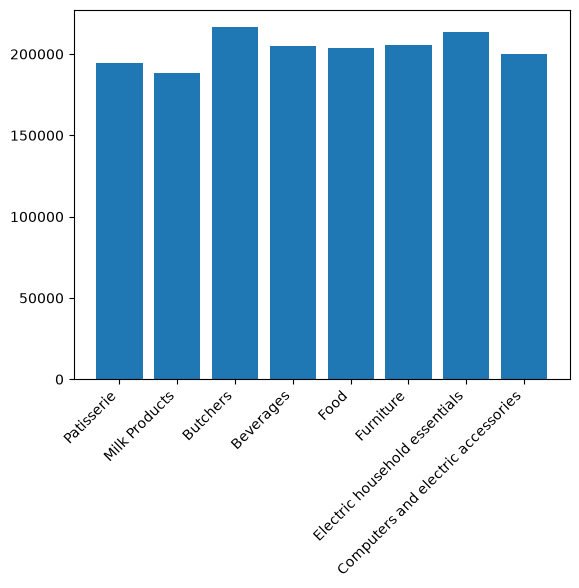

In [81]:
#total spent by ctg
totalSpent={}
for ctg in ctg_unq:
    totalSpent[ctg]=data[data["Category"]==ctg]["Total Spent"].sum()
totalSpent
plt.bar(range(len(totalSpent)), list(totalSpent.values()),tick_label=list(totalSpent.keys()))
plt.xticks(rotation=45,ha='right')


In [ ]:
#Total spent is very similar in each situation, because of the dummy data.


In [82]:
data.groupby("Discount Applied")["Total Spent"].mean()

Discount Applied
False    128.006052
True     130.777000
Name: Total Spent, dtype: float64

In [ ]:
#Applied discount increased the Total Spent slightly